In [4]:
!pip install selenium
!apt-get update
!apt install chromium-chromedriver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.4.0
    Uninstalling urllib3-2.4.0:
      Successfully uninstalled urllib3-2.4.0
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 h

In [28]:
from selenium import webdriver
from bs4 import BeautifulSoup
from datetime import datetime
import re
from sklearn.preprocessing import LabelEncoder

In [20]:
# Set up headless Chrome browser
options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.5481.178 Safari/537.36")

driver = webdriver.Chrome(options=options)
url = "https://www.bbc.com/weather/293397"
driver.get(url)
driver.implicitly_wait(5)
soup = BeautifulSoup(driver.page_source, 'html.parser')
driver.quit()

# Find all daily forecast blocks
forecasts = soup.find_all("li", class_="wr-day")
weather_data = []

for forecast in forecasts:
    # Get the date text
    date_tag = forecast.find("div", class_="wr-day__title")
    raw_date = date_tag.text.strip() if date_tag else "N/A"
    match = re.search(r'(\d{1,2})(?:st|nd|rd|th)?\s+([A-Za-z]+)', raw_date)
    wd_match = re.search(r'(Mon|Tue|Wed|Thu|Fri|Sat|Sun)', raw_date)

    # Format date as "Mon 14.07"
    if match and wd_match:
        day = match.group(1).zfill(2)
        weekday = wd_match.group(1)
        month = datetime.now().month
        date = f"{weekday} {day}.{month:02d}"
    else:
        date = raw_date

In [ ]:
# Get max temperature
    temp_max_tag = forecast.find("span", class_="wr-day-temperature__high-value")
    temp_max = temp_max_tag.text.strip().replace("°", "") if temp_max_tag else "N/A"
    temp_max = temp_max.split()[0] if temp_max != "N/A" else "N/A"

    # Get min temperature
    temp_min_tag = forecast.find("span", class_="wr-day-temperature__low-value")
    temp_min = temp_min_tag.text.strip().replace("°", "") if temp_min_tag else "N/A"
    temp_min = temp_min.split()[0] if temp_min != "N/A" else "N/A"

    # Get weather condition
    condition_tag = forecast.find("span", class_="wr-day__weather-type-description")
    if not condition_tag:
        condition_tag = forecast.find("div", class_="wr-day__details__weather-type-description")
    weather_condition = condition_tag.text.strip() if condition_tag else "N/A"

    # Add data to the list
    weather_data.append({
        "Date": date,
        "Min Temperature (°C)": temp_min,
        "Max Temperature (°C)": temp_max,
        "Weather Condition": weather_condition
    })

**Data Analysis with Pandas:**

* Load your scraped data into a Pandas DataFrame.


In [22]:
# Print table
import pandas as pd
df = pd.DataFrame(weather_data)
df

,Date,Min Temperature (°C),Max Temperature (°C),Weather Condition
0,Today,22,29,Sunny and a gentle breeze
1,Mon 14.07,21,29,Sunny and a gentle breeze
2,Tue 15.07,21,30,Sunny and a gentle breeze
3,Wed 16.07,22,31,Sunny and a gentle breeze
4,Thu 17.07,22,32,Sunny and a gentle breeze
5,Fri 18.07,22,31,Sunny and a gentle breeze
6,Sat 19.07,23,30,Sunny and a gentle breeze
7,Sun 20.07,23,31,Sunny and a gentle breeze
8,Mon 21.07,23,31,Sunny and a gentle breeze
9,Tue 22.07,23,31,Sunny and a gentle breeze


* Clean and preprocess the data if necessary (handling missing values, type conversion, etc.).


In [23]:
# Missing values
df.isnull().sum()

,0
Date,0
Min Temperature (°C),0
Max Temperature (°C),0
Weather Condition,0


In [24]:
df.describe()

,Date,Min Temperature (°C),Max Temperature (°C),Weather Condition
count,14,14,14,14
unique,14,3,4,1
top,Today,22,31,Sunny and a gentle breeze
freq,1,6,9,14


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  14 non-null     object
 1   Min Temperature (°C)  14 non-null     object
 2   Max Temperature (°C)  14 non-null     object
 3   Weather Condition     14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


In [26]:
# Converting Temperature object into int
df['Max Temperature (°C)'] = df['Max Temperature (°C)'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  14 non-null     object
 1   Min Temperature (°C)  14 non-null     object
 2   Max Temperature (°C)  14 non-null     int64 
 3   Weather Condition     14 non-null     object
dtypes: int64(1), object(3)
memory usage: 580.0+ bytes


In [31]:
# Encoding Weather Condition into categorical values
label_encoder = LabelEncoder()

df["Weather Encoded"] = label_encoder.fit_transform(df["Weather Condition"])

In [32]:
df

,Date,Min Temperature (°C),Max Temperature (°C),Weather Condition,Weather Encoded
0,Today,22,29,Sunny and a gentle breeze,0
1,Mon 14.07,21,29,Sunny and a gentle breeze,0
2,Tue 15.07,21,30,Sunny and a gentle breeze,0
3,Wed 16.07,22,31,Sunny and a gentle breeze,0
4,Thu 17.07,22,32,Sunny and a gentle breeze,0
5,Fri 18.07,22,31,Sunny and a gentle breeze,0
6,Sat 19.07,23,30,Sunny and a gentle breeze,0
7,Sun 20.07,23,31,Sunny and a gentle breeze,0
8,Mon 21.07,23,31,Sunny and a gentle breeze,0
9,Tue 22.07,23,31,Sunny and a gentle breeze,0


* Perform basic analysis, such as calculating averages, totals, or trends over time.


In [33]:
# Average Temperature
average_temp = df["Max Temperature (°C)"].mean()
print(f"Average Temperature on the 2 next weeks: {average_temp:.2f}°C")

Average Temperature on the 2 next weeks: 30.64°C


In [34]:
# Trends
most_common_condition = df["Weather Condition"].value_counts().idxmax()
print(f"The most common weather condition will be: {most_common_condition}")

The most common weather condition will be: Sunny and a gentle breeze


**Data Visualization with Seaborn and Matplotlib:**

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

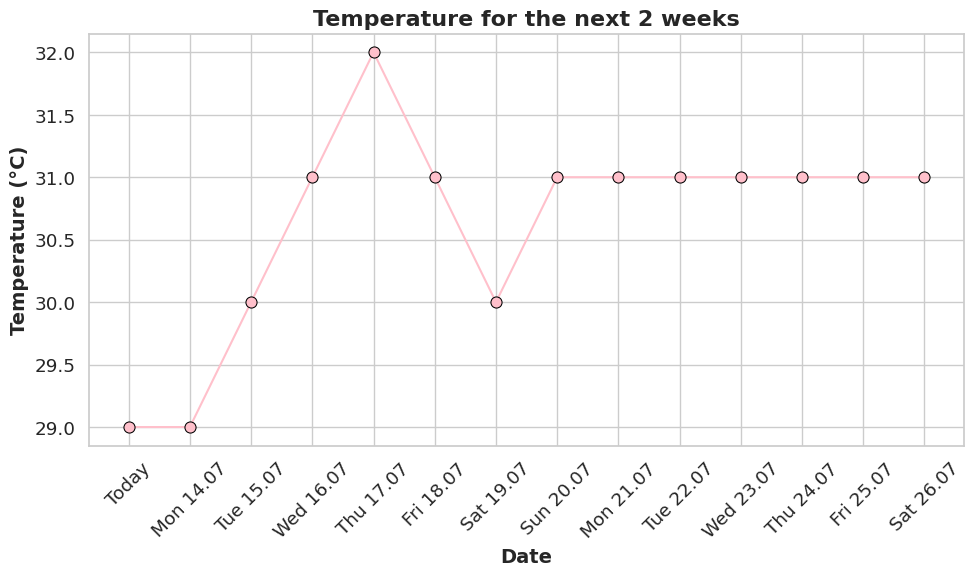

In [46]:
# Temperature over time
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="Date", y="Max Temperature (°C)", color='pink', marker='o', markeredgecolor='black', markersize=8)
plt.title("Temperature for the next 2 weeks", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Temperature (°C)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)

plt.show()


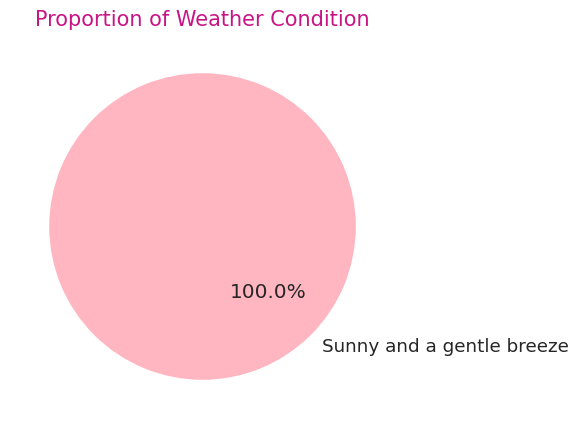

In [50]:
pink_colors = ["#ffb6c1", "#ff69b4", "#ff1493", "#db7093", "#c71585"]

plt.figure(figsize=(7, 5))
plt.pie(
    condition_counts,
    labels=condition_counts.index,
    autopct="%1.1f%%",
    colors=pink_colors[:len(condition_counts)],
    startangle=135
)
plt.title("Proportion of Weather Condition", fontsize=15, color="#c71585")
plt.show()

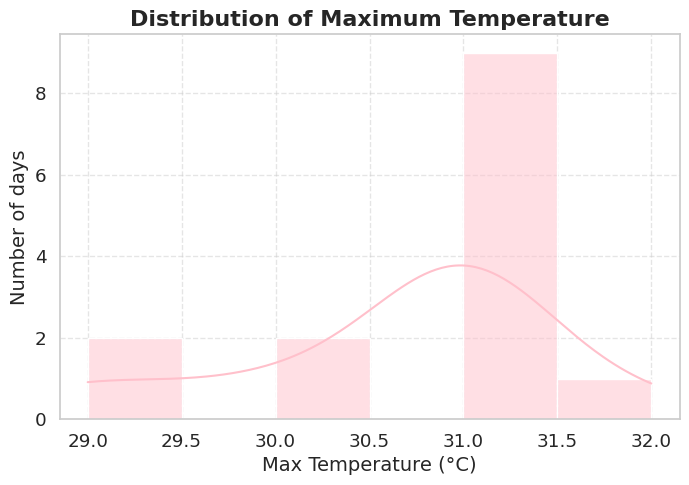

In [48]:
# Histogramme
plt.figure(figsize=(8, 5))
sns.histplot(df["Max Temperature (°C)"], bins=6, kde=True, color="pink")

plt.title("Distribution of Maximum Temperature", fontsize=16, fontweight="bold")
plt.xlabel("Max Temperature (°C)", fontsize=14)
plt.ylabel("Number of days", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Weather Data Analysis: Tel Aviv

## Scraping the Data

- Weather data for **Tel Aviv** was collected from the [BBC Weather](https://www.bbc.com/weather/293397) website using **Selenium** and **BeautifulSoup**.
- The dataset includes:
  - **Maximum and minimum daily temperatures** for the next two weeks.
  - **Daily weather conditions** (e.g., *Sunny and a gentle breeze*, *Light rain*).
- All collected data was organized into a **Pandas DataFrame** for analysis.

## Data Analysis with Pandas

- Checked for and handled **missing values**.
- Encoded **categorical weather conditions** into numeric values for analysis.

## Data Visualization

- **Line Plot:** The daily max temperature rises early in the period, peaking at `32°C`, then stabilizes between `30°C` and `31°C` towards the end.
- **Pie Chart:** The most frequent weather condition during this period is **"Sunny and a gentle breeze"**.
- **Histogram:** The most common temperatures are around **31°C**, with several days reaching this value.

## Conclusion

- The forecast for Tel Aviv indicates **predominantly sunny days with gentle breezes**.
- Most days will experience maximum temperatures between **30°C and 32°C**, suggesting warm and stable weather conditions.
- This information can help **residents and visitors plan** their activities and prepare for typical weather patterns expected in Tel Aviv.